In [17]:
import numpy as np
import pandas as pd
from astropy.table import Table
import matplotlib.pyplot as plt
import astropy.units as u
import treecorr

In [2]:
import os, sys

In [14]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
pdir = os.getenv("PSCRATCH")

In [40]:
nbins = 10
min_sep = 6 / 60
max_sep = 150 / 60
ss_config = {
    "nbins": nbins,
    "min_sep": min_sep,
    "max_sep": max_sep,
    "bin_type": "Log",
    "bin_size": np.log(max_sep / min_sep) / nbins,
    "bin_slop": 0.1,
    "flip_g1": False,
    "flip_g2": True,
}

In [5]:
# ra,dec,gamma1,gamma2,kappa,zs,ei,weight,e1,e2,bflag,rf_blend
zsb_file = pdir + f'/buzzard_hp/data/zsb_deconvolved/csvs/zsb3_rftag_icut.csv'

In [6]:
zsb_dat = np.loadtxt(zsb_file, delimiter=',', skiprows=1)

In [41]:
zsb_subset = zsb_dat[:1000000,:]
weights = zsb_subset[:,7]

In [81]:
zsb_flag = zsb_subset[:,-1] >= 40/100
blends = np.where(zsb_flag)[0]

In [82]:
weights[blends] = weights[blends]*(1-zsb_dat[blends,-1]**2)

In [74]:
# filt = zsb_subset[:,-1] <= 40/100

In [83]:
cat = treecorr.Catalog(ra=zsb_subset[:,0], dec=zsb_subset[:,1],
                       g1=zsb_subset[:,8], g2=zsb_subset[:,9],
                       ra_units='deg', dec_units='deg',
                       w=weights,
                       flip_g1=False, flip_g2=True) 

In [84]:
gg = treecorr.GGCorrelation(
    min_sep=ss_config["min_sep"],
    max_sep=ss_config["max_sep"],
    nbins=ss_config["nbins"],
    bin_type=ss_config["bin_type"],
    bin_slop=ss_config["bin_slop"],
    var_method="shot",
    sep_units="degrees",
    verbose=2
)

gg.process(cat)

nbins = 10, min,max sep = 0.1..2.5 deg, bin_size = 0.321888
Starting process GG auto-correlations
Using 256 threads.
Starting 1024 jobs.
...............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [85]:
rf = gg.copy()
# pure = gg.copy()
# full = gg.copy()

In [86]:
plot_ggs = [full, pure, rf]
plot_names = ['full','pure', 'rf']

Text(0.02, 0.5, '$10^4\\times \\theta\\xi_+$')

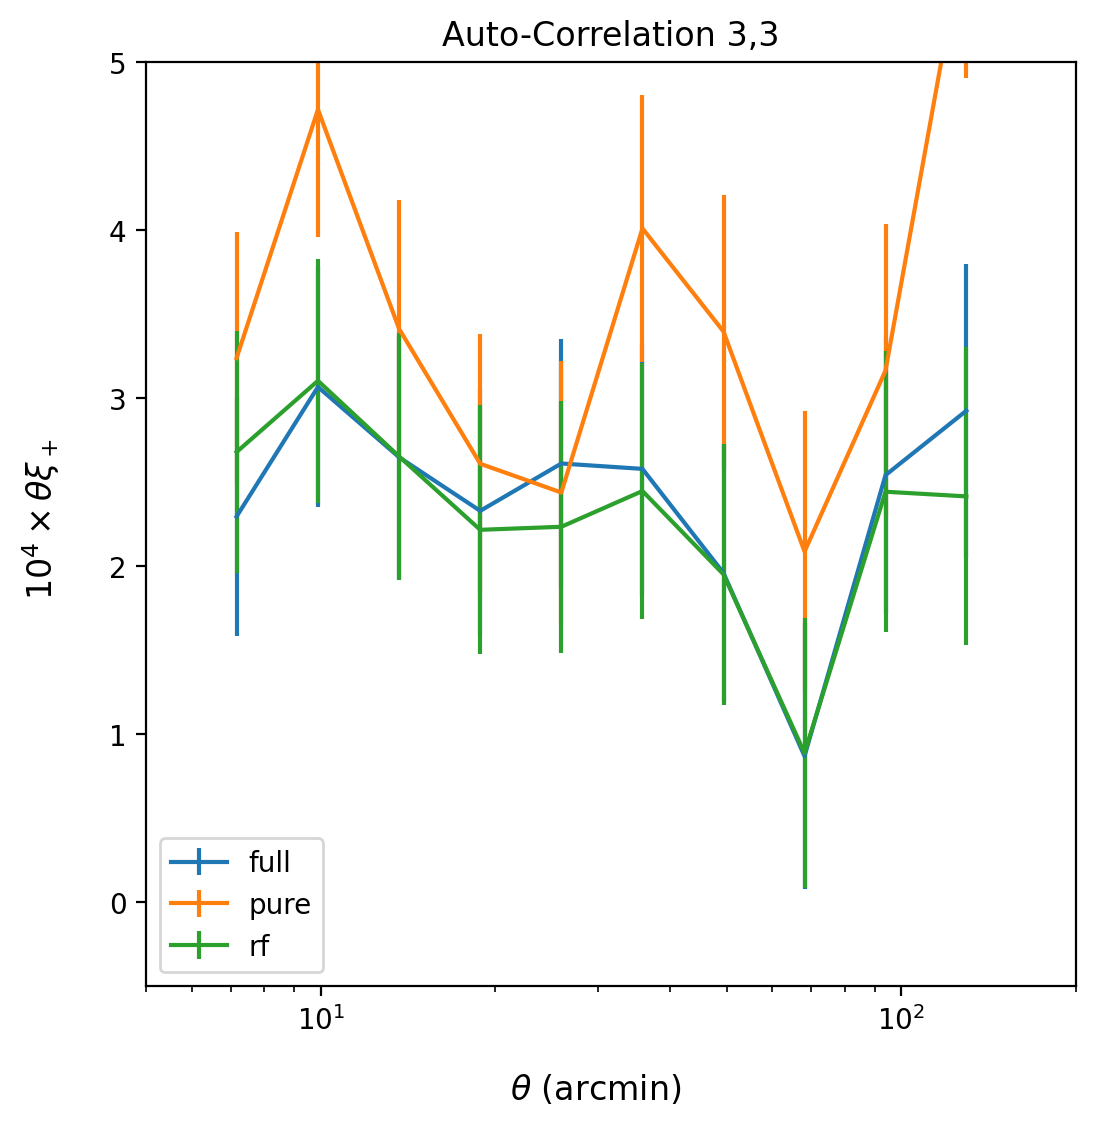

In [87]:
fig, ax = plt.subplots(1, figsize=(6,6))

ax.set_title(f"Auto-Correlation 3,3")

for i, gg in enumerate(plot_ggs):
    r = np.exp(gg.meanlogr) * 60
    xip = gg.xip * 1e4
    xim = gg.xim * 1e4
    sig = np.sqrt(gg.varxip)* 1e4
    
    # ax.plot(r, xip * r)
    # ax[ix,iy].plot(r, -xip * r, color='blue', ls=':')
    lp = ax.errorbar(r, xip * r, yerr=sig * r, alpha=1, label=plot_names[i])
    ax.semilogx()
    # plt.yscale('log', nonpositive='clip')

ax.set_xlim( [5,200] )
ax.set_ylim([-.5,5])

fig.supxlabel(r'$\theta$ (arcmin)')
ax.legend()
# fig.legend(legends[-len(gg_names):], [r'RF 50 $\xi_+(\theta)$', 
#                                       r'RF 50 Linear Weighting $\xi_+(\theta)$',
#                                       r'RF 50 Quadratic Weighting $\xi_+(\theta)$'],
#            frameon=False, bbox_to_anchor=(1.4,.6), fontsize=15)
fig.supylabel(r'$10^4\times \theta\xi_+$')